# 02 — Analyse Exploratoire des Données (EDA)

**Projet :** Heatwave-ML  
**Objectif :** Comprendre et visualiser le dataset nettoyé — distributions, tendances, corrélations, label `is_heatwave`



In [ ]:
# ── Imports ───────────────────────────────────────────────────
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

print('Librairies importées')

✅ Librairies importées


In [ ]:
# ── Configuration projet
PROJECT_ROOT = "/content/drive/MyDrive/heatwave-ml"

drive.mount('/content/drive')
os.chdir(PROJECT_ROOT)

for folder in ['figures', 'data/processed']:
    os.makedirs(folder, exist_ok=True)

# Style global unique
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f' Setup terminé')
print(f'Répertoire : {os.getcwd()}')

Mounted at /content/drive
 Setup terminé
Répertoire : /content/drive/MyDrive/heatwave-ml


In [ ]:

# Chargement
df = pd.read_parquet('data/processed/heatwave_merged.parquet')

# Extraire Year et Month depuis date
df['Year']  = df['date'].dt.year
df['Month'] = df['date'].dt.month

In [ ]:
# Palette régions
regions      = df['Region'].unique()
color_by_reg = dict(zip(regions, sns.color_palette('tab10', len(regions))))

MOIS = ['Jan','Fév','Mar','Avr','Mai','Jun',
        'Jul','Aoû','Sep','Oct','Nov','Déc']

print(f"Shape  : {df.shape}")
print(f"Villes : {df['City_clean'].nunique()}")
print(f"Période: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Régions: {list(regions)}")

Shape  : (343579, 14)
Villes : 101
Période: 2009-12-31 → 2020-05-13
Régions: ['Africa', 'Asia', 'Australia/South Pacific', 'Europe', 'Middle East', 'North America', 'South/Central America & Carribean']


In [ ]:
# Statistiques descriptives
cols_stats = ['AvgTemperature_C', 'temp_max', 'temp_min',
              'humidity', 'precip_mm', 'wind_kph', 'heat_index']
print('\n STATISTIQUES DESCRIPTIVES')
print(df[cols_stats].describe().round(2))


📊 STATISTIQUES DESCRIPTIVES
       AvgTemperature_C   temp_max   temp_min   humidity  precip_mm  \
count         343579.00  343579.00  343579.00  343579.00  343579.00   
mean              18.82      22.49      14.42      71.39       2.72   
std                9.63       9.77       9.42      16.68       6.63   
min              -25.89     -26.25     -34.19       3.81       0.00   
25%               12.89      16.65       8.34      63.37       0.00   
50%               20.72      24.80      15.70      75.40       0.10   
75%               26.61      29.49      22.71      83.60       2.50   
max               43.33      49.25      36.60      99.94     296.90   

        wind_kph  heat_index  
count  343579.00   343579.00  
mean       16.72       22.84  
std         7.19       12.44  
min         2.28      -32.33  
25%        11.38       14.66  
50%        15.55       25.31  
75%        20.63       33.07  
max       101.42       49.61  


/tmp/ipykernel_21997/4003034117.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_region, labels=regions, patch_artist=True)


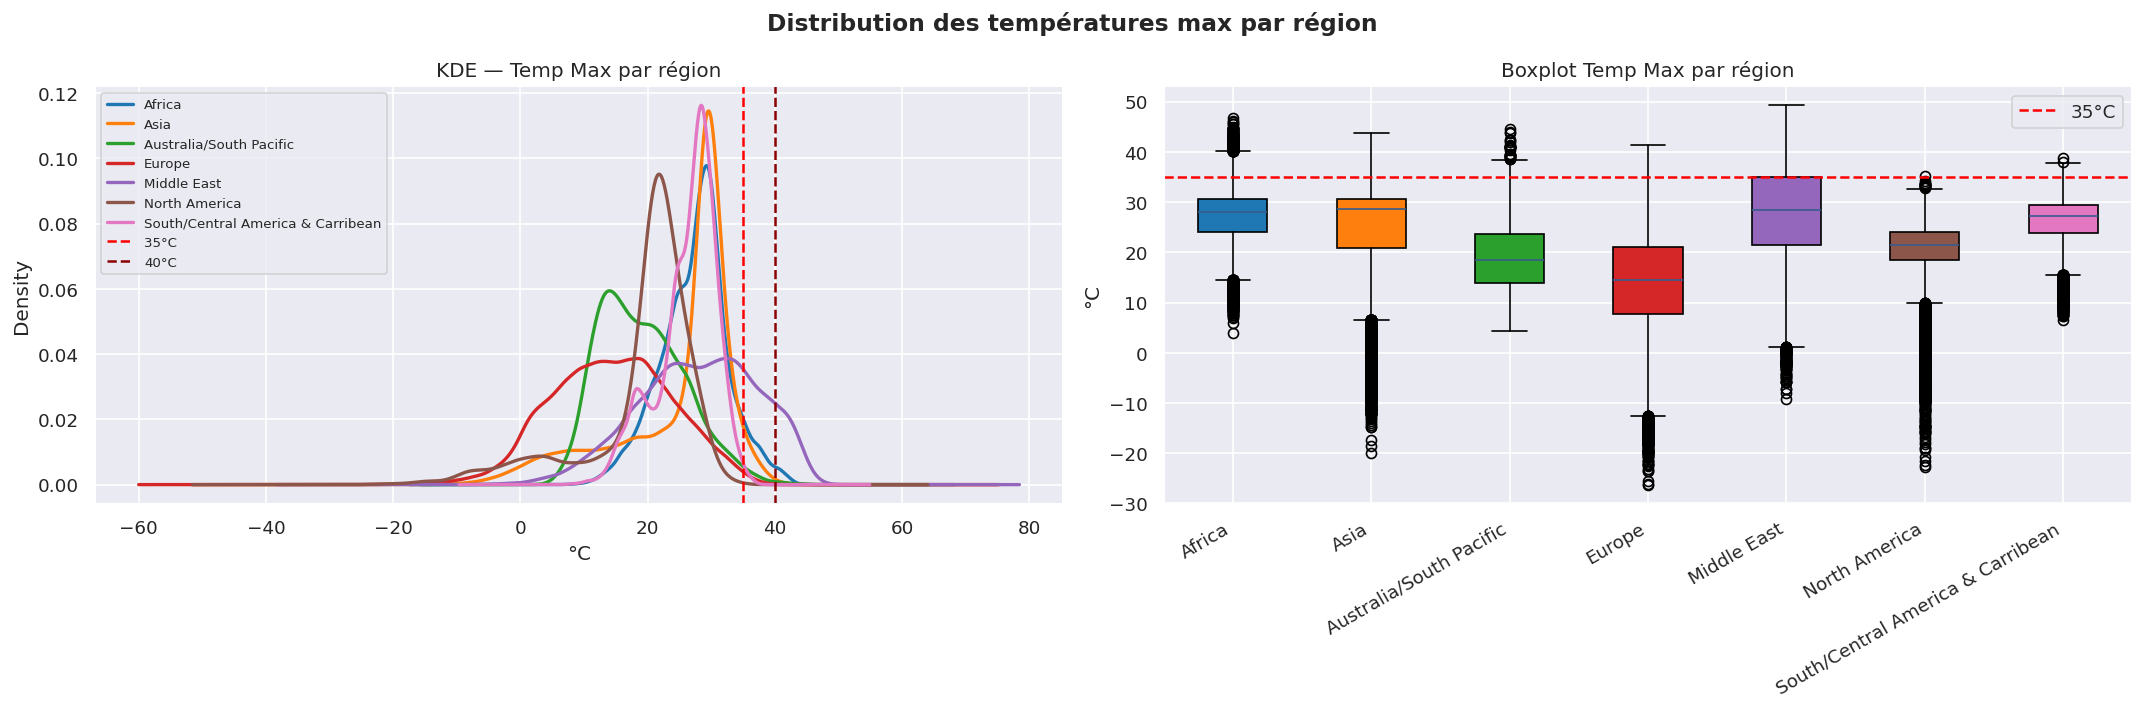

In [ ]:
# Partie 2 — Distribution des températures par région

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for region in regions:
    df[df['Region'] == region]['temp_max'].plot.kde(
        ax=axes[0], label=region, color=color_by_reg[region], linewidth=2
    )
for seuil, couleur, label in [(35, 'red', '35°C'), (40, 'darkred', '40°C')]:
    axes[0].axvline(seuil, color=couleur, linestyle='--', linewidth=1.5, label=label)
axes[0].set_title('KDE — Temp Max par région')
axes[0].set_xlabel('°C')
axes[0].legend(fontsize=8)

data_by_region = [df[df['Region'] == r]['temp_max'].values for r in regions]
bp = axes[1].boxplot(data_by_region, labels=regions, patch_artist=True)
for patch, region in zip(bp['boxes'], regions):
    patch.set_facecolor(color_by_reg[region])
axes[1].axhline(35, color='red', linestyle='--', linewidth=1.5, label='35°C')
axes[1].set_title('Boxplot Temp Max par région')
axes[1].set_ylabel('°C')
axes[1].set_xticklabels(regions, rotation=30, ha='right')
axes[1].legend()

plt.suptitle('Distribution des températures max par région', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_distribution_regions.png', dpi=150, bbox_inches='tight')
plt.show()

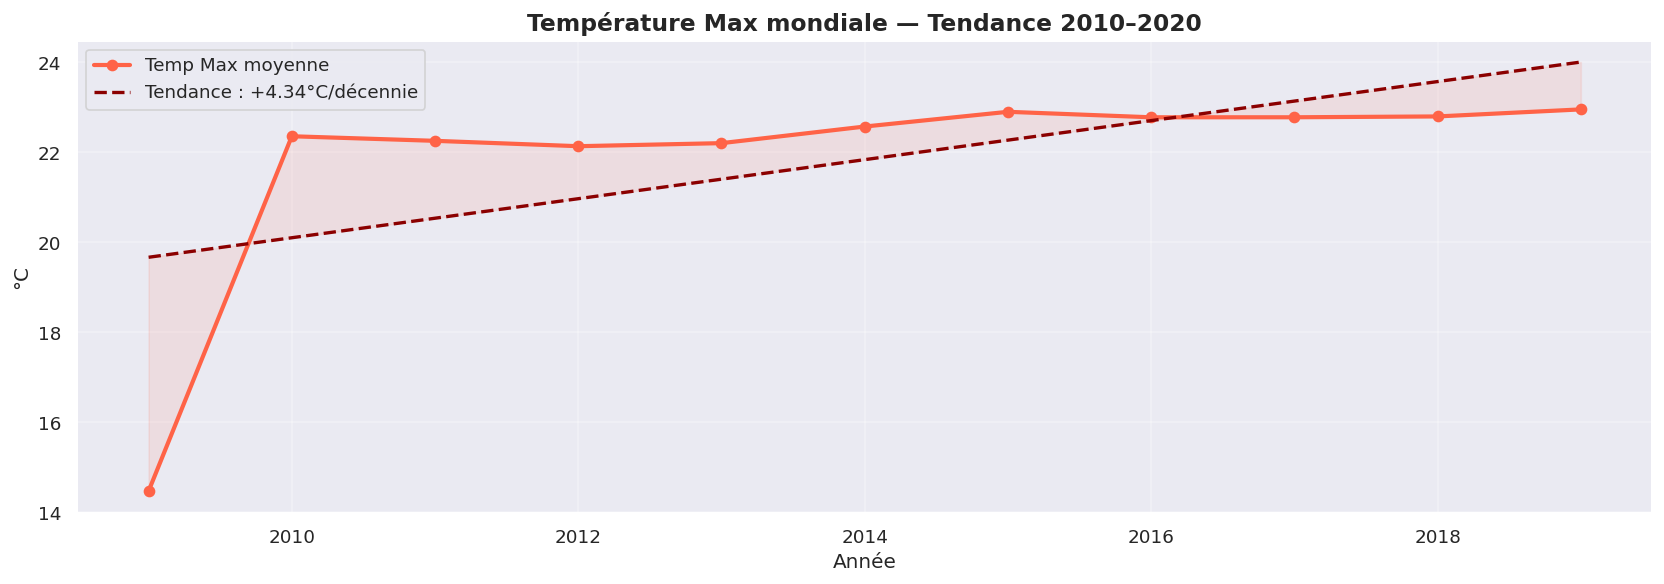

Tendance : +4.337°C/décennie


In [ ]:
# Partie 3 — Tendance climatique 2010–2020

annual   = df[df['Year'] < 2020].groupby('Year')['temp_max'].mean().reset_index()
z        = np.polyfit(annual['Year'], annual['temp_max'], 1)
p        = np.poly1d(z)
tendance = z[0] * 10  

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(annual['Year'], annual['temp_max'],
        color='tomato', linewidth=2.5, marker='o', label='Temp Max moyenne')
ax.plot(annual['Year'], p(annual['Year']),
        color='darkred', linewidth=2, linestyle='--',
        label=f'Tendance : {tendance:+.2f}°C/décennie')
ax.fill_between(annual['Year'], annual['temp_max'], p(annual['Year']),
                alpha=0.1, color='tomato')
ax.set_title('Température Max mondiale — Tendance 2010–2020', fontsize=14, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('°C')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/03_tendance_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Tendance : {tendance:+.3f}°C/décennie')

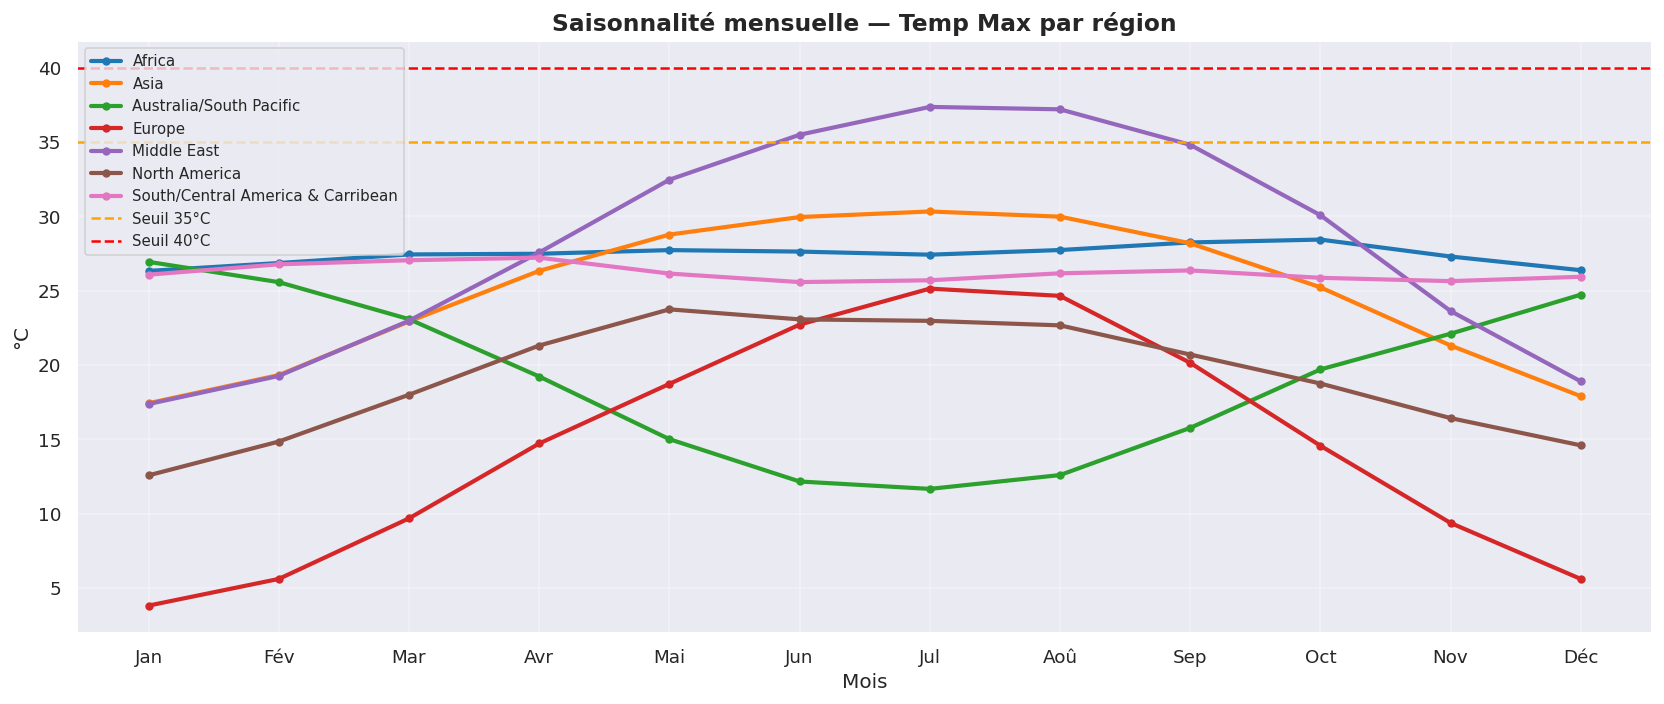

In [ ]:

# Partie 4 — Saisonnalité mensuelle par région

monthly = df.groupby(['Region', 'Month'])['temp_max'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for region in regions:
    subset = monthly[monthly['Region'] == region]
    ax.plot(subset['Month'], subset['temp_max'],
            label=region, color=color_by_reg[region],
            linewidth=2.5, marker='o', markersize=4)
ax.axhline(35, color='orange', linestyle='--', linewidth=1.5, label='Seuil 35°C')
ax.axhline(40, color='red',    linestyle='--', linewidth=1.5, label='Seuil 40°C')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MOIS)
ax.set_title('Saisonnalité mensuelle — Temp Max par région', fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('°C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/04_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

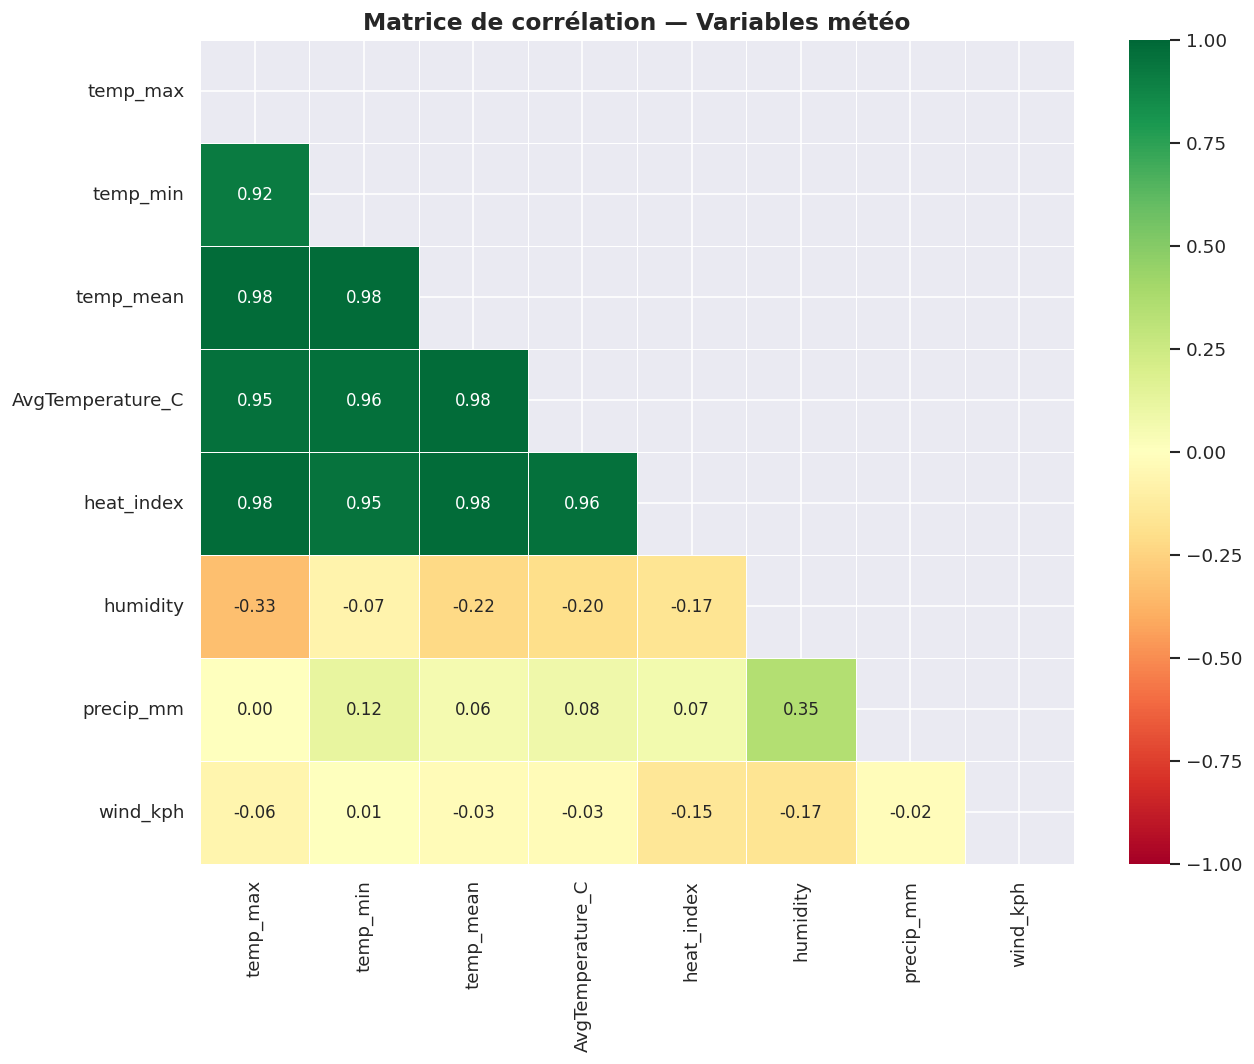

Corrélations avec temp_max :
   temp_mean            : +0.980
   heat_index           : +0.979
   AvgTemperature_C     : +0.954
   temp_min             : +0.922
   precip_mm            : +0.003
   wind_kph             : -0.064
   humidity             : -0.331


In [ ]:


# Partie 5 — Matrice de corrélation

cols_corr = ['temp_max', 'temp_min', 'temp_mean', 'AvgTemperature_C',
             'heat_index', 'humidity', 'precip_mm', 'wind_kph']

corr = df[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Matrice de corrélation — Variables météo', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top corrélations avec temp_max
print('Corrélations avec temp_max :')
corr_tm = corr['temp_max'].drop('temp_max').sort_values(ascending=False)
for col, val in corr_tm.items():
    print(f'   {col:<20} : {val:+.3f}')


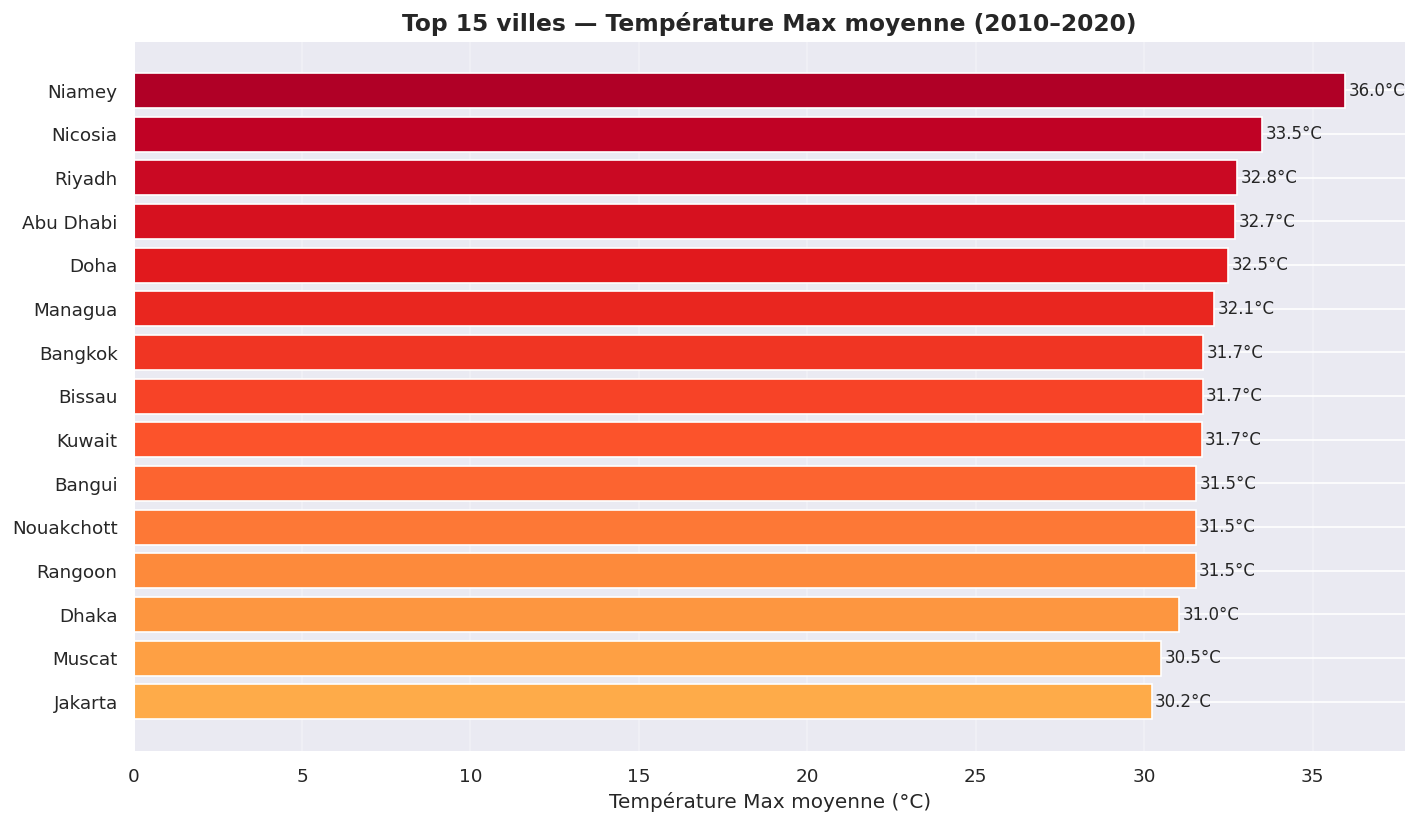

In [ ]:
# Partie 6 — Top 15 villes les plus chaudes

top15      = df.groupby('City_clean')['temp_max'].mean().sort_values(ascending=False).head(15)
colors_bar = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top15)))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors_bar)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}°C', va='center', fontsize=10)
ax.set_title('Top 15 villes — Température Max moyenne (2010–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Température Max moyenne (°C)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/06_top15_villes.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_21997/1292771112.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


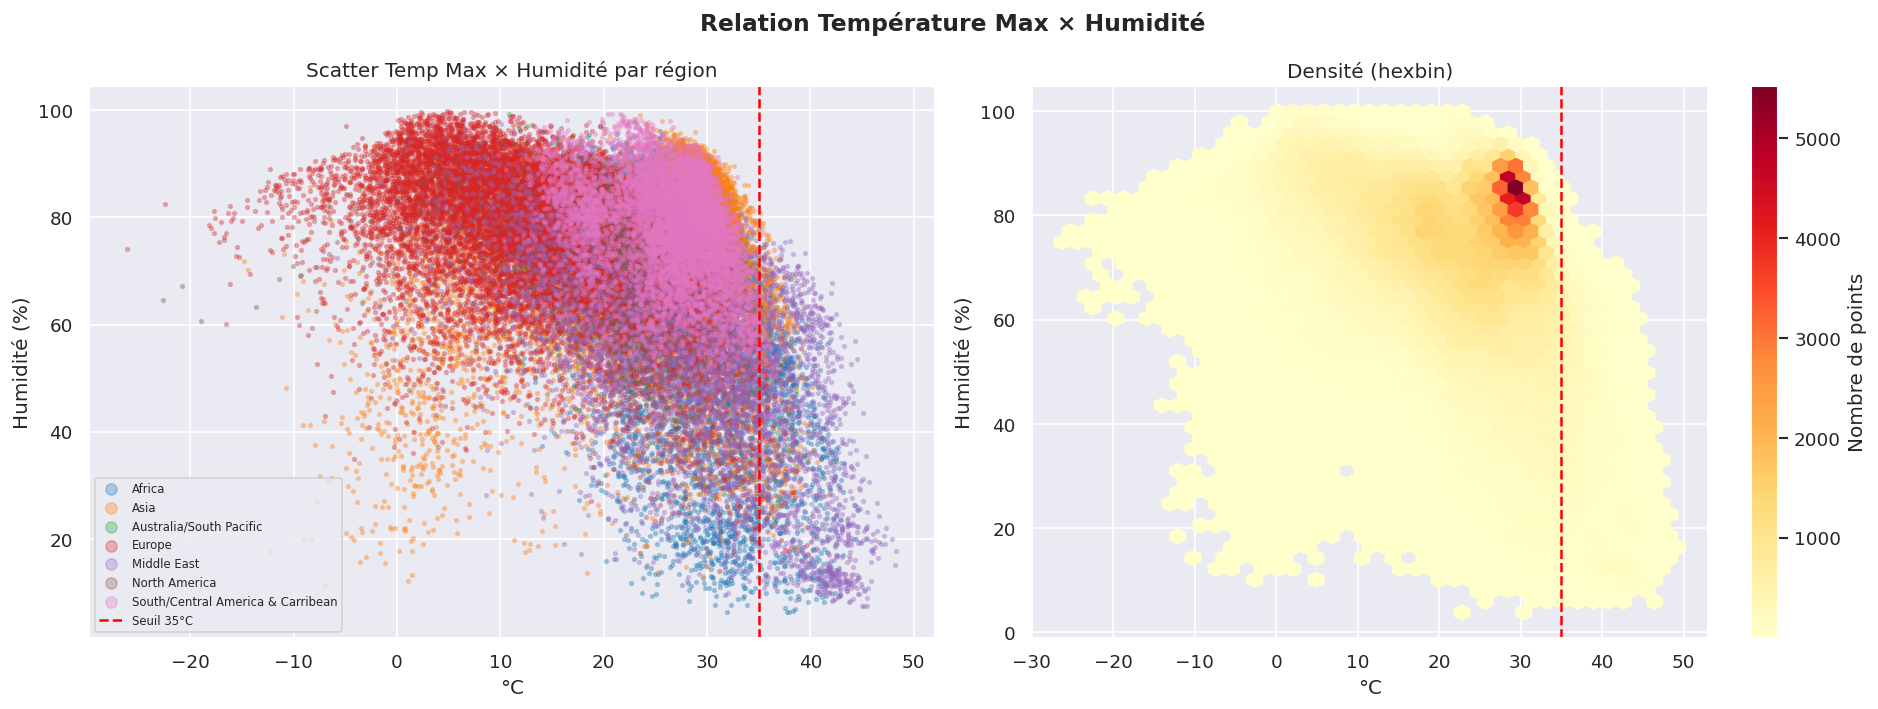


✅ EDA Partie 1→7 terminée
⏭  Prochain : Créer is_heatwave → puis Parties 8, 9, 10


In [ ]:

# Partie 7 — Relation Temp Max × Humidité

sample = df.sample(min(50_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for region in regions:
    s = sample[sample['Region'] == region]
    axes[0].scatter(s['temp_max'], s['humidity'],
                    alpha=0.3, s=5, color=color_by_reg[region], label=region)
axes[0].axvline(35, color='red', linestyle='--', linewidth=1.5, label='Seuil 35°C')
axes[0].set_title('Scatter Temp Max × Humidité par région')
axes[0].set_xlabel('°C')
axes[0].set_ylabel('Humidité (%)')
axes[0].legend(fontsize=7, markerscale=3)

hb = axes[1].hexbin(df['temp_max'], df['humidity'], gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='Nombre de points')
axes[1].axvline(35, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Densité (hexbin)')
axes[1].set_xlabel('°C')
axes[1].set_ylabel('Humidité (%)')

plt.suptitle('Relation Température Max × Humidité', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/07_temp_humidite.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n EDA Partie 1→7 terminée')


In [ ]:

# Création de la variable cible is_heatwave


# ── Définition du seuil
SEUIL_HEATWAVE = 35  # °C

# ── Création du label
df['is_heatwave'] = (df['temp_max'] >= SEUIL_HEATWAVE).astype(int)

# ── Vérification
counts  = df['is_heatwave'].value_counts()
ratio   = counts[0] // counts[1]

print("=" * 50)
print("CRÉATION is_heatwave")
print("=" * 50)
print(f"Seuil utilisé     : temp_max >= {SEUIL_HEATWAVE}°C")
print(f"Classe 0 (Normal) : {counts[0]:,} ({counts[0]/len(df)*100:.2f}%)")
print(f"Classe 1 (Vague)  : {counts[1]:,} ({counts[1]/len(df)*100:.2f}%)")
print(f"Ratio déséquilibre: 1:{ratio}")
print(f"\nShape df          : {df.shape}")

CRÉATION is_heatwave
Seuil utilisé     : temp_max >= 35°C
Classe 0 (Normal) : 325,867 (94.84%)
Classe 1 (Vague)  : 17,712 (5.16%)
Ratio déséquilibre: 1:18

Shape df          : (343579, 15)


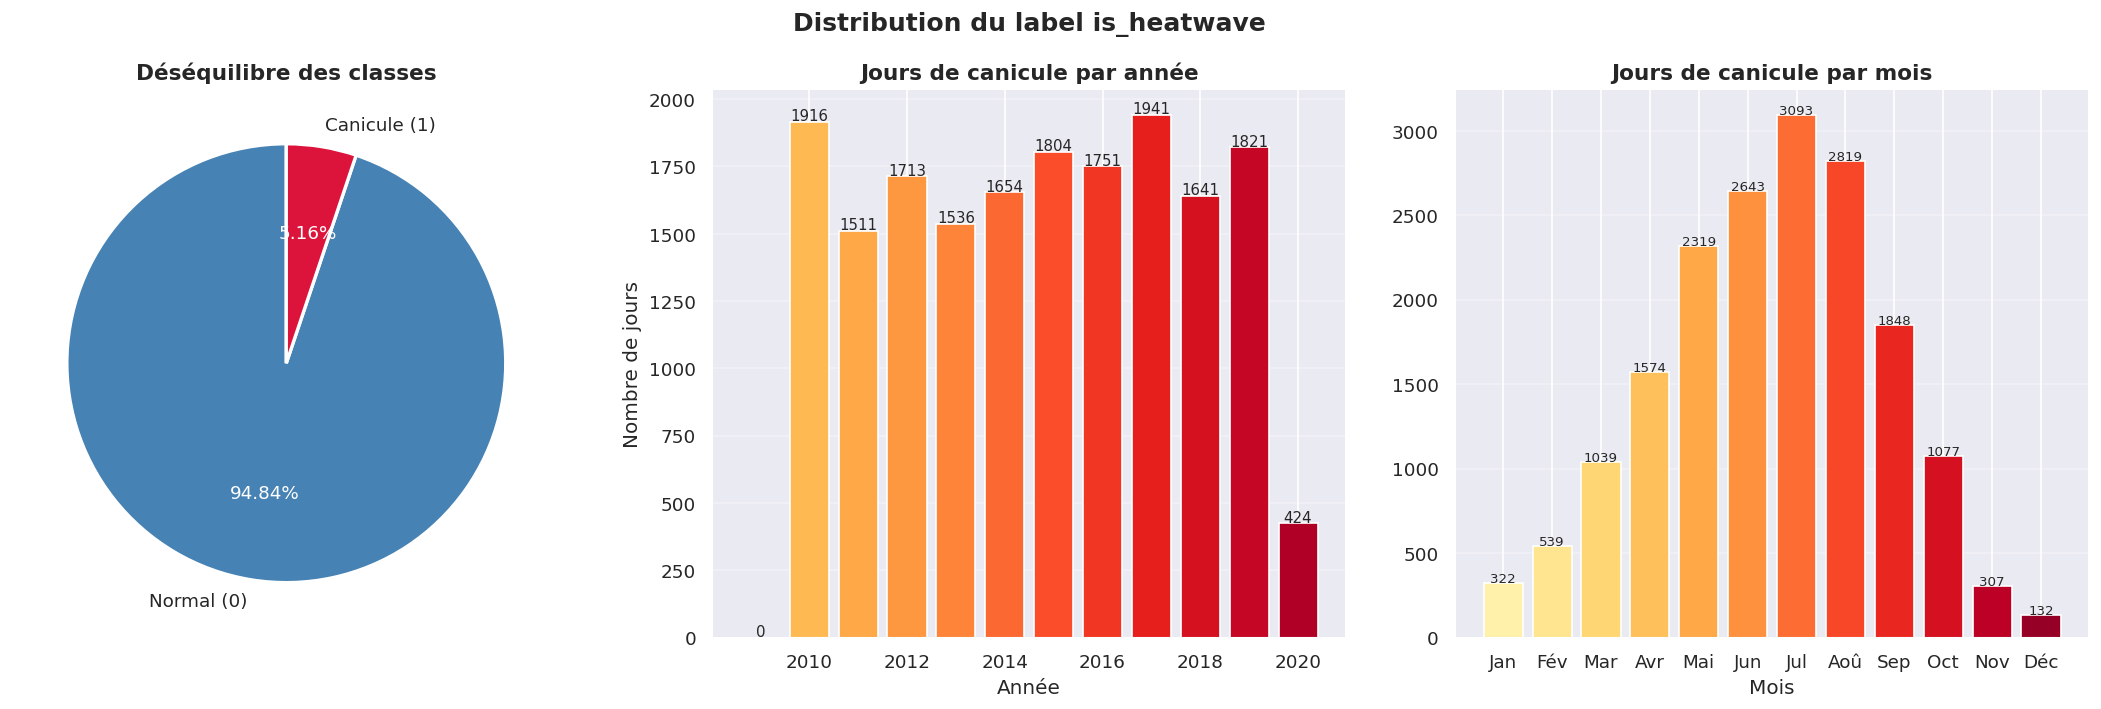

Classe 0 : 325,867 (94.84%) | Classe 1 : 17,712 (5.16%) | Ratio : 1:18
⚠ Déséquilibre → prévoir class_weight='balanced' ou SMOTE


In [ ]:
counts   = df['is_heatwave'].value_counts()
hw_year  = df.groupby('Year')['is_heatwave'].sum()
hw_month = df.groupby('Month')['is_heatwave'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Camembert
wedges, texts, autotexts = axes[0].pie(
    counts.values,
    labels=['Normal (0)', 'Canicule (1)'],
    colors=['steelblue', 'crimson'],
    autopct='%1.2f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white')
axes[0].set_title('Déséquilibre des classes', fontsize=13, fontweight='bold')

# Par année
colors_y = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(hw_year)))
bars = axes[1].bar(hw_year.index, hw_year.values, color=colors_y)
for bar, val in zip(bars, hw_year.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5, str(val), ha='center', fontsize=9)
axes[1].set_title('Jours de canicule par année', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de jours')
axes[1].grid(True, alpha=0.3, axis='y')

# Par mois
colors_m = plt.cm.YlOrRd(np.linspace(0.1, 0.95, 12))
bars = axes[2].bar(MOIS, hw_month.values, color=colors_m)
for bar, val in zip(bars, hw_month.values):
    if val > 0:
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 5, str(val), ha='center', fontsize=8)
axes[2].set_title('Jours de canicule par mois', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Mois')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Distribution du label is_heatwave', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/08_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts[0] // counts[1] if counts[1] > 0 else 'N/A'
print(f"Classe 0 : {counts[0]:,} ({counts[0]/len(df)*100:.2f}%) | "
      f"Classe 1 : {counts[1]:,} ({counts[1]/len(df)*100:.2f}%) | "
      f"Ratio : 1:{ratio}")


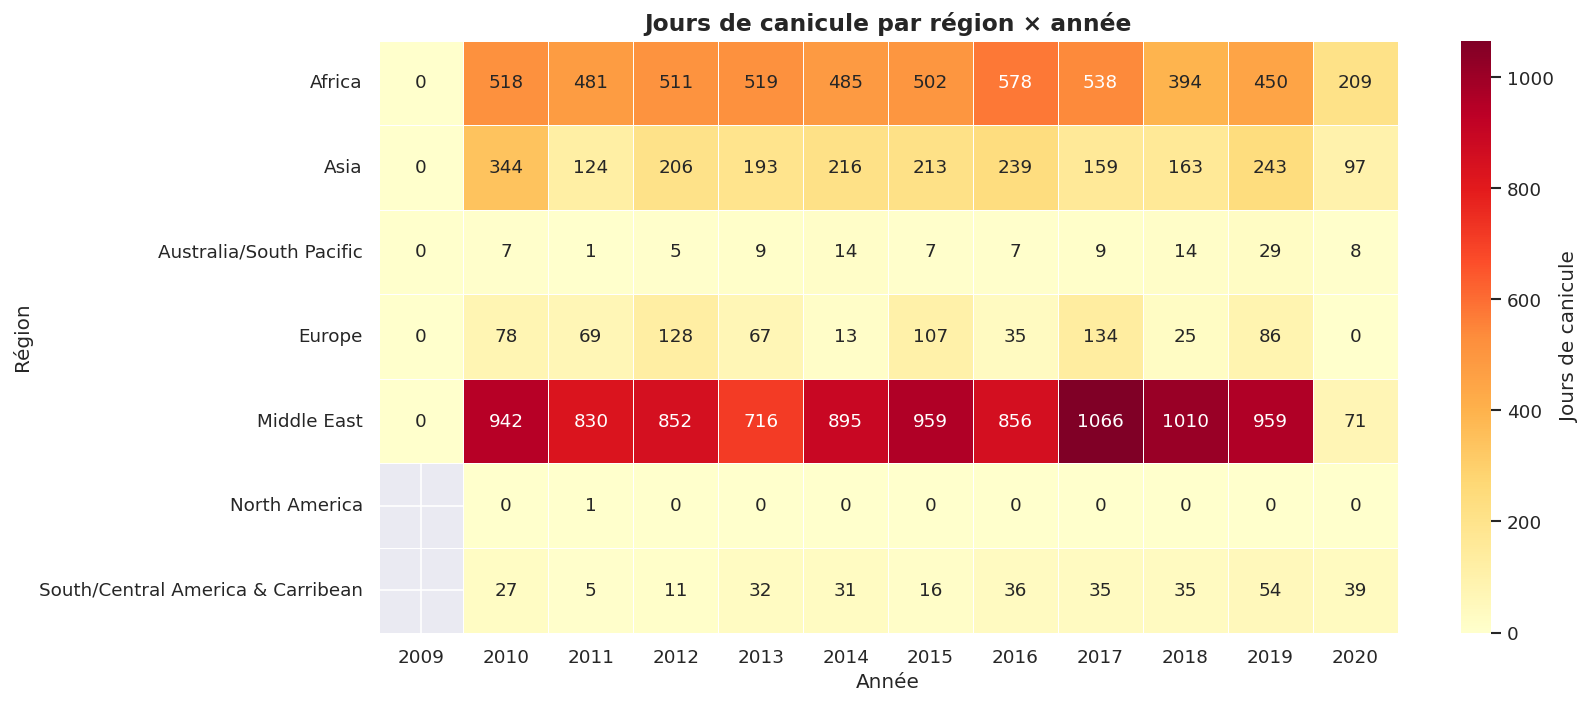

In [ ]:
pivot = df.groupby(['Region', 'Year'])['is_heatwave'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Jours de canicule'})
ax.set_title('Jours de canicule par région × année', fontsize=14, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Région')

plt.tight_layout()
plt.savefig('figures/09_heatmap_region_annee.png', dpi=150, bbox_inches='tight')
plt.show()


**Partie 10 — Taux de canicule par ville et région**

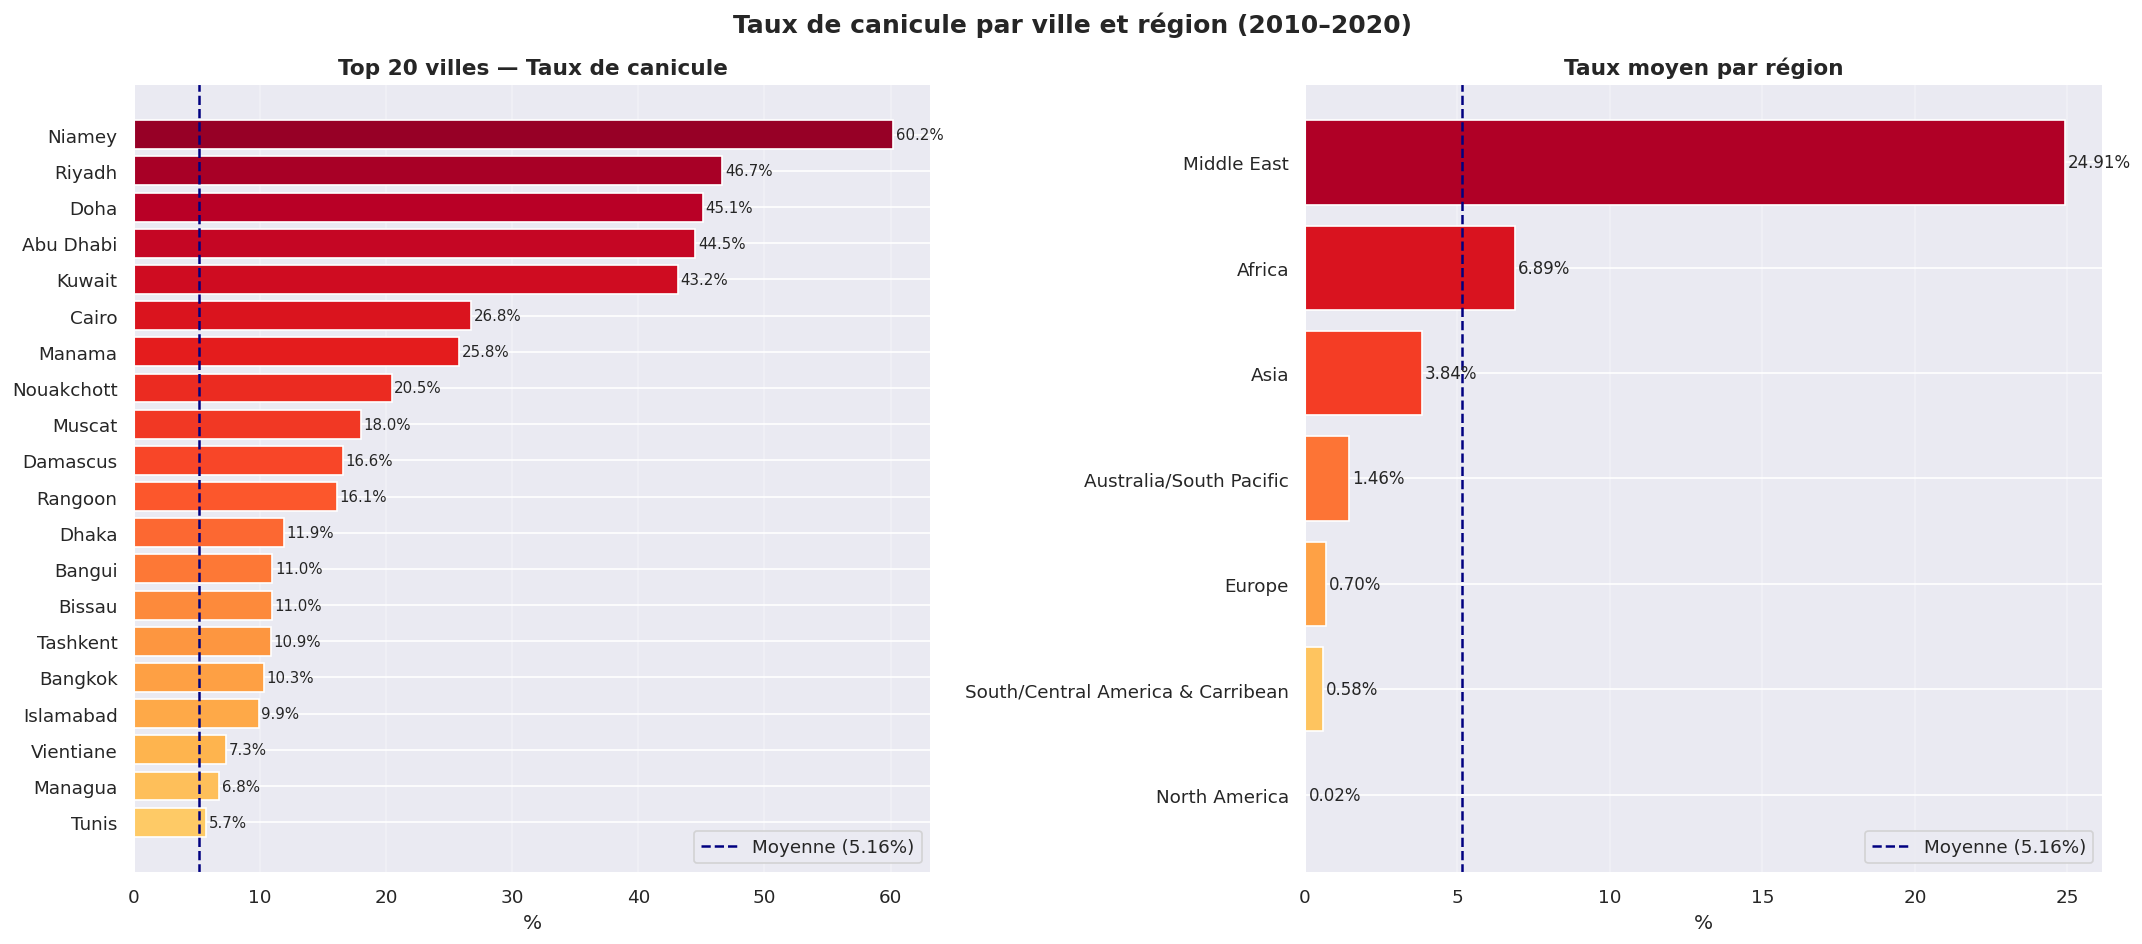


✅ EDA terminée — 10 figures sauvegardées dans /figures/


In [ ]:
city_hw = (
    df.groupby(['City_clean', 'Region'])['is_heatwave']
      .agg(total_jours='sum', taux='mean')
      .reset_index()
)
city_hw['taux_pct'] = city_hw['taux'] * 100
city_hw = city_hw.sort_values('taux_pct', ascending=False)

moyenne_globale = df['is_heatwave'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top20    = city_hw.head(20)
colors_t = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(top20)))
bars = axes[0].barh(top20['City_clean'][::-1], top20['taux_pct'][::-1], color=colors_t)
for bar, val in zip(bars, top20['taux_pct'][::-1]):
    axes[0].text(bar.get_width() + 0.2,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].axvline(moyenne_globale, color='navy', linestyle='--', linewidth=1.5,
                label=f'Moyenne ({moyenne_globale:.2f}%)')
axes[0].set_title('Top 20 villes — Taux de canicule', fontsize=13, fontweight='bold')
axes[0].set_xlabel('%')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

region_hw = (df.groupby('Region')['is_heatwave'].mean() * 100).sort_values()
colors_r  = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(region_hw)))
bars = axes[1].barh(region_hw.index, region_hw.values, color=colors_r)
for bar, val in zip(bars, region_hw.values):
    axes[1].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}%', va='center', fontsize=10)
axes[1].axvline(moyenne_globale, color='navy', linestyle='--', linewidth=1.5,
                label=f'Moyenne ({moyenne_globale:.2f}%)')
axes[1].set_title('Taux moyen par région', fontsize=13, fontweight='bold')
axes[1].set_xlabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Taux de canicule par ville et région (2010–2020)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/10_taux_canicule_villes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n EDA terminée — 10 figures sauvegardées dans /figures/')


In [ ]:
# Sauvegarde du dataset final avec is_heatwave
output_path = 'data/processed/heatwave_final.parquet'
df.to_parquet(output_path, index=False)
print(f"Dataset sauvegardé : {output_path}")
print(f"   Shape : {df.shape}")
print(f"   Colonnes : {list(df.columns)}")

✅ Dataset sauvegardé : data/processed/heatwave_final.parquet
   Shape : (343579, 15)
   Colonnes : ['Region', 'Country', 'AvgTemperature_C', 'date', 'City_clean', 'temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph', 'Year', 'Month', 'is_heatwave']


In [ ]:
print("=" * 50)
print("RÉSUMÉ EDA FINAL")
print("=" * 50)
print(f"Lignes totales     : {len(df):,}")
print(f"Villes             : {df['City_clean'].nunique()}")
print(f"Période            : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Features           : {list(df.columns)}")
print(f"Canicules (1)      : {df['is_heatwave'].sum():,} ({df['is_heatwave'].mean()*100:.2f}%)")
print(f"Normaux (0)        : {(df['is_heatwave']==0).sum():,}")
print(f"Année incomplète   : 2020 → à exclure des tendances temporelles")


RÉSUMÉ EDA FINAL
Lignes totales     : 343,579
Villes             : 101
Période            : 2009-12-31 → 2020-05-13
Features           : ['Region', 'Country', 'AvgTemperature_C', 'date', 'City_clean', 'temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph', 'Year', 'Month', 'is_heatwave']
Canicules (1)      : 17,712 (5.16%)
Normaux (0)        : 325,867
Année incomplète   : 2020 → à exclure des tendances temporelles


In [ ]:
df

,Region,Country,AvgTemperature_C,date,City_clean,temp_max,temp_min,temp_mean,heat_index,humidity,precip_mm,wind_kph,Year,Month,is_heatwave
0,Africa,Algeria,13.833333,2009-12-31,Algiers,15.255500,12.305500,13.734668,9.279676,67.873260,1.9,45.173901,2009,12,0
1,Africa,Algeria,15.055556,2010-01-01,Algiers,15.105500,9.855500,13.440915,12.161535,73.278656,0.0,28.116899,2010,1,0
2,Africa,Algeria,13.111111,2010-01-02,Algiers,16.805500,9.555500,12.770082,16.533545,82.930679,0.0,10.495713,2010,1,0
3,Africa,Algeria,10.833333,2010-01-03,Algiers,17.905500,11.155500,14.132584,17.307453,78.689552,0.0,16.676977,2010,1,0
4,Africa,Algeria,11.833333,2010-01-04,Algiers,17.005501,12.405500,14.174249,12.713257,70.067093,3.7,31.608328,2010,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343574,South/Central America & Carribean,Venezuela,26.944444,2020-05-08,Caracas,32.210499,20.410500,25.366751,33.826351,60.683811,0.0,14.825706,2020,5,0
343575,South/Central America & Carribean,Venezuela,27.388889,2020-05-09,Caracas,31.460499,20.660500,25.235498,33.717121,59.983883,0.0,16.750641,2020,5,0
343576,South/Central America & Carribean,Venezuela,26.777778,2020-05-10,Caracas,30.810499,19.210499,24.395912,33.298370,61.447453,0.0,12.015589,2020,5,0
343577,South/Central America & Carribean,Venezuela,27.277778,2020-05-11,Caracas,31.510500,20.210499,25.185499,34.608536,59.743317,0.0,11.720751,2020,5,0
